In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("play_tennis.csv")

df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [4]:
df.tail()

,day,outlook,temp,humidity,wind,play
9,D10,Rain,Mild,Normal,Weak,Yes
10,D11,Sunny,Mild,Normal,Strong,Yes
11,D12,Overcast,Mild,High,Strong,Yes
12,D13,Overcast,Hot,Normal,Weak,Yes
13,D14,Rain,Mild,High,Strong,No


In [5]:
df.shape

(14, 6)

In [6]:
df.columns

Index(['day', 'outlook', 'temp', 'humidity', 'wind', 'play'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day       14 non-null     object
 1   outlook   14 non-null     object
 2   temp      14 non-null     object
 3   humidity  14 non-null     object
 4   wind      14 non-null     object
 5   play      14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [8]:
df.describe(include="all")

,day,outlook,temp,humidity,wind,play
count,14,14,14,14,14,14
unique,14,3,3,2,2,2
top,D1,Sunny,Mild,High,Weak,Yes
freq,1,5,6,7,8,9


In [9]:
df.isnull().sum()

day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking unique values in each column

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


day:
['D1' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'D8' 'D9' 'D10' 'D11' 'D12' 'D13'
 'D14']

outlook:
['Sunny' 'Overcast' 'Rain']

temp:
['Hot' 'Mild' 'Cool']

humidity:
['High' 'Normal']

wind:
['Weak' 'Strong']

play:
['No' 'Yes']


In [12]:
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [18]:
df["play"].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

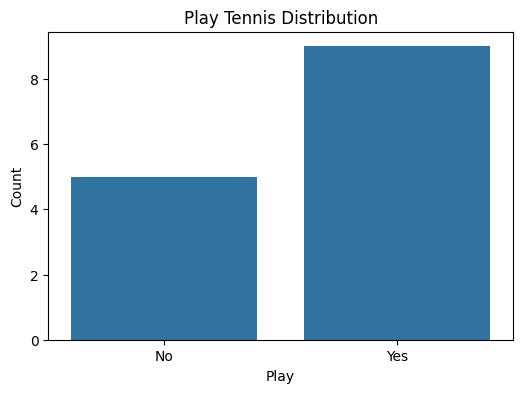

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="play"
)

plt.title("Play Tennis Distribution")
plt.xlabel("Play")
plt.ylabel("Count")

plt.show()

In [20]:
pd.crosstab(
    df["outlook"],
    df["play"]
)

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


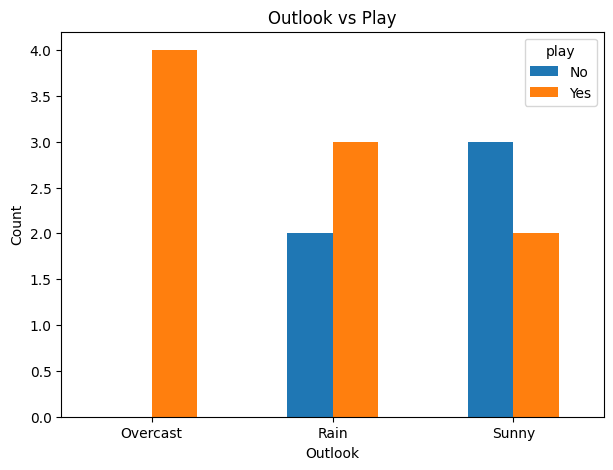

In [21]:
pd.crosstab(
    df["outlook"],
    df["play"]
).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Outlook vs Play")
plt.xlabel("Outlook")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [22]:
pd.crosstab(
    df["temp"],
    df["play"]
)

play,No,Yes
temp,,
Cool,1,3
Hot,2,2
Mild,2,4


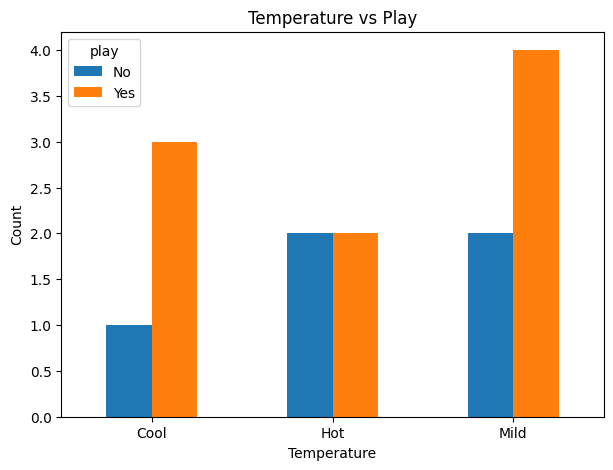

In [23]:
pd.crosstab(
    df["temp"],
    df["play"]
).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Temperature vs Play")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [24]:
pd.crosstab(
    df["humidity"],
    df["play"]
)

play,No,Yes
humidity,,
High,4,3
Normal,1,6


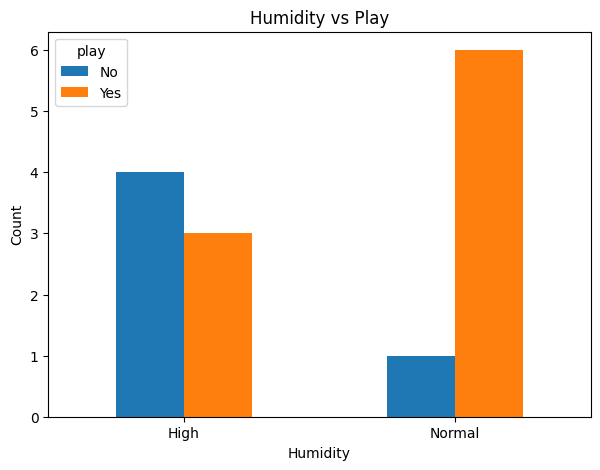

In [25]:
pd.crosstab(
    df["humidity"],
    df["play"]
).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Humidity vs Play")
plt.xlabel("Humidity")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [26]:
pd.crosstab(
    df["wind"],
    df["play"]
)

play,No,Yes
wind,,
Strong,3,3
Weak,2,6


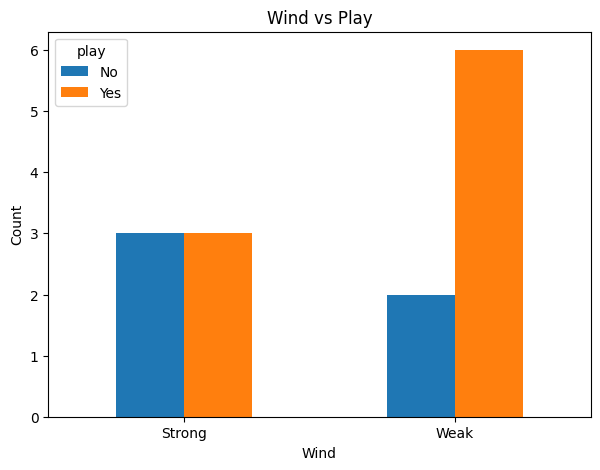

In [27]:
pd.crosstab(
    df["wind"],
    df["play"]
).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Wind vs Play")
plt.xlabel("Wind")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [28]:
X = df[
    [
        "outlook",
        "temp",
        "humidity",
        "wind"
    ]
]

y = df["play"]

In [29]:
print("X:")
display(X)

print("\ny:")
display(y)

X:


,outlook,temp,humidity,wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak
5,Rain,Cool,Normal,Strong
6,Overcast,Cool,Normal,Strong
7,Sunny,Mild,High,Weak
8,Sunny,Cool,Normal,Weak
9,Rain,Mild,Normal,Weak



y:


0      No
1      No
2     Yes
3     Yes
4     Yes
5      No
6     Yes
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13     No
Name: play, dtype: object

In [30]:
X_encoded = X.copy()

encoders = {}

for column in X_encoded.columns:

    encoder = LabelEncoder()

    X_encoded[column] = encoder.fit_transform(
        X_encoded[column]
    )

    encoders[column] = encoder

In [31]:
X_encoded

,outlook,temp,humidity,wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1


In [32]:
for column, encoder in encoders.items():

    print(f"\n{column}")

    for value, encoded_value in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ):
        print(
            f"{value} → {encoded_value}"
        )


outlook
Overcast → 0
Rain → 1
Sunny → 2

temp
Cool → 0
Hot → 1
Mild → 2

humidity
High → 0
Normal → 1

wind
Strong → 0
Weak → 1


In [33]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(y_encoded)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [34]:
for value, encoded_value in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(
        f"{value} → {encoded_value}"
    )

No → 0
Yes → 1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

In [36]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (9, 4)
Testing data : (5, 4)


In [37]:
model = CategoricalNB()

In [38]:
model.fit(
    X_train,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [39]:
y_pred = model.predict(X_test)

print("Actual:", y_test)
print("Predicted:", y_pred)

Actual: [1 1 0 1 0]
Predicted: [1 1 1 1 1]


In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.6
Accuracy (%): 60.0


In [41]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[0 2]
 [0 3]]


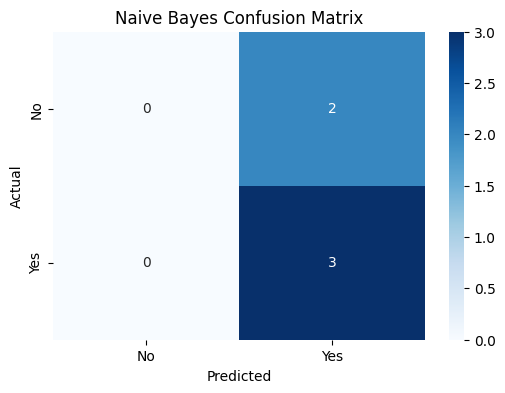

In [43]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    CategoricalNB(),
    X_encoded,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Fold Accuracies: [0.66666667 1.         0.66666667 0.         0.5       ]
Mean Accuracy: 0.5666666666666667
